# Logistische Regression: Maximum-Likelihood-Klassifikation von Grund auf

**Notebook 02 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Dieses Notebook entwickelt die logistische Regression als Maximum-Likelihood-Schätzer
für ein Bernoulli-Modell binärer Zielgrößen. Aus der Log-Likelihood wird die
Kreuzentropie-Verlustfunktion hergeleitet, deren Konvexität gezeigt und über
Gradientenabstieg minimiert wird — konsistent mit dem in Notebook 00, Abschnitt 4
entwickelten Rahmen. Die Eigenimplementierung wird gegen `scikit-learn` validiert,
Entscheidungsgrenzen auf linear und nicht-linear trennbaren Datensätzen visualisiert
und Klassifikationsgüte über Konfusionsmatrix, ROC-Kurve und Kalibrierung beurteilt.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. die logistische Regression als MLE für ein Bernoulli-Modell herleiten,
2. die Konvexität der Kreuzentropie begründen und den Gradienten herleiten,
3. Entscheidungsgrenzen linearer Klassifikatoren geometrisch interpretieren,
4. Accuracy, Precision, Recall, F1-Score und ROC-AUC unterscheiden und ihre jeweilige
   Aussagekraft bei unbalancierten Klassen einschätzen,
5. Kalibrierung von Diskriminierungsfähigkeit unterscheiden.

## Inhalt

1. [Problemstellung](#1)
2. [Theoretischer Rahmen](#2)
3. [Rechenumgebung](#3)
4. [Datengrundlage](#4)
5. [Implementierung](#5)
6. [Empirische Analyse](#6)
7. [Diskussion und Grenzen](#7)
8. [Übungsaufgaben](#8)
9. [Literatur](#9)

<a id="1"></a>
## 1 Problemstellung

Gegeben sei $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^n$ mit $\mathbf{x}_i\in\mathbb{R}^p$
und binärer Zielgröße $y_i\in\{0,1\}$. Gesucht ist ein Modell für
$P(y=1\mid\mathbf{x})$. Eine direkte lineare Modellierung
$P(y=1\mid\mathbf{x})=\tilde{\mathbf{x}}^\top\boldsymbol\beta$ ist ungeeignet, da die
rechte Seite Werte außerhalb $[0,1]$ annehmen kann. Die logistische Regression
modelliert stattdessen den **Logit** (Log-Odds) als linear:

$$
\log\frac{P(y=1\mid\mathbf{x})}{1-P(y=1\mid\mathbf{x})} = \tilde{\mathbf{x}}^\top\boldsymbol\beta .
$$

<a id="2"></a>
## 2 Theoretischer Rahmen

### 2.1 Die logistische Funktion

Auflösen nach $P(y=1\mid\mathbf{x})$ liefert die Sigmoid-Funktion

$$
\sigma(z) = \frac{1}{1+e^{-z}}, \qquad
P(y=1\mid\mathbf{x}) = \sigma\bigl(\tilde{\mathbf{x}}^\top\boldsymbol\beta\bigr).
$$

Es gilt $\sigma'(z) = \sigma(z)\bigl(1-\sigma(z)\bigr)$ und $\sigma(z)\in(0,1)$ für alle
endlichen $z$ — die Modellannahme ist damit für Wahrscheinlichkeiten konsistent.

### 2.2 Maximum-Likelihood-Herleitung

Unter der Annahme $y_i\mid\mathbf{x}_i \sim \operatorname{Bernoulli}(p_i)$ mit
$p_i=\sigma(\tilde{\mathbf{x}}_i^\top\boldsymbol\beta)$ ist die Likelihood der
Stichprobe (Notebook 00, Abschnitt 3.2)

$$
L(\boldsymbol\beta) = \prod_{i=1}^n p_i^{\,y_i}(1-p_i)^{1-y_i}.
$$

Die Log-Likelihood ist

$$
\ell(\boldsymbol\beta) = \sum_{i=1}^n \Bigl[y_i\log p_i + (1-y_i)\log(1-p_i)\Bigr].
$$

Die **Kreuzentropie** $J(\boldsymbol\beta) = -\tfrac{1}{n}\ell(\boldsymbol\beta)$ ist die
zu minimierende Verlustfunktion; ihre Minimierung ist äquivalent zur
Maximum-Likelihood-Schätzung.

### 2.3 Gradient und Konvexität

Mit $z_i=\tilde{\mathbf{x}}_i^\top\boldsymbol\beta$ und der Kettenregel
($\partial p_i/\partial\boldsymbol\beta = p_i(1-p_i)\tilde{\mathbf{x}}_i$) ergibt sich
nach Vereinfachung der bemerkenswert kompakte Gradient

$$
\nabla_{\boldsymbol\beta} J(\boldsymbol\beta)
  = \frac{1}{n}\sum_{i=1}^n \bigl(p_i - y_i\bigr)\,\tilde{\mathbf{x}}_i
  = \frac{1}{n}\,\tilde X^\top(\mathbf{p}-\mathbf{y}),
$$

formal identisch zum Gradienten der linearen Regression (Notebook 01, Abschnitt 2.3),
nur mit $\mathbf{p}=\sigma(\tilde X\boldsymbol\beta)$ statt $\tilde X\boldsymbol\beta$.
Die Hesse-Matrix

$$
\nabla^2_{\boldsymbol\beta} J(\boldsymbol\beta)
  = \frac{1}{n}\tilde X^\top W \tilde X, \qquad
  W = \operatorname{diag}\bigl(p_i(1-p_i)\bigr)
$$

ist wegen $p_i(1-p_i)\ge 0$ positiv semidefinit — $J$ ist folglich **konvex**
(Notebook 00, Abschnitt 4.1), und Gradientenabstieg konvergiert gegen das globale
Minimum.

### 2.4 Entscheidungsgrenze

Die Klassifikationsregel $\hat y=\mathbb{1}[P(y=1\mid\mathbf{x})\ge 0.5]$ ist äquivalent
zu $\hat y=\mathbb{1}[\tilde{\mathbf{x}}^\top\boldsymbol\beta\ge 0]$: Die
Entscheidungsgrenze ist die **Hyperebene** $\tilde{\mathbf{x}}^\top\boldsymbol\beta=0$.
Logistische Regression erzeugt somit ausschließlich lineare Entscheidungsgrenzen im
Merkmalsraum — Abschnitt 6.2 zeigt die Konsequenz für nicht-linear trennbare Daten.

### 2.5 Klassifikationsgütemaße

Aus der Konfusionsmatrix (TP, FP, TN, FN) ergeben sich

$$
\text{Precision} = \frac{TP}{TP+FP}, \qquad
\text{Recall} = \frac{TP}{TP+FN}, \qquad
F_1 = \frac{2\cdot\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}} .
$$

Die **ROC-Kurve** trägt die True-Positive-Rate (Recall) gegen die
False-Positive-Rate $FP/(FP+TN)$ für alle Schwellenwerte $\tau\in[0,1]$ auf; die Fläche
darunter (AUC) ist schwellenwert-unabhängig und entspricht der Wahrscheinlichkeit, dass
ein zufällig gezogener positiver Fall einen höheren Score erhält als ein zufällig
gezogener negativer Fall.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5),
        "figure.dpi": 110,
        "font.size": 10,
        "axes.grid": True,
        "axes.axisbelow": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.3,
        "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)

print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}, scikit-learn {sklearn.__version__}")

Python 3.11.15, NumPy 2.4.6, scikit-learn 1.9.0


<a id="4"></a>
## 4 Datengrundlage

Zwei Szenarien werden untersucht: ein linear trennbarer Datensatz (Modellannahme
korrekt erfüllt) und ein nicht-linear trennbarer Halbmond-Datensatz (Modellannahme
verletzt), um die in Abschnitt 2.4 genannte Grenze linearer Klassifikatoren sichtbar zu
machen.

In [2]:
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split

X_lin, y_lin = make_classification(
    n_samples=300, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, class_sep=1.8, flip_y=0.03, random_state=RANDOM_STATE,
)
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X_lin, y_lin, test_size=0.3, random_state=RANDOM_STATE, stratify=y_lin
)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons
)

print(f"linear trennbar : n_train={len(X_train)}, n_test={len(X_test)}, "
      f"Klassenverteilung train={np.bincount(y_train)}")
print(f"Halbmonde       : n_train={len(Xm_train)}, n_test={len(Xm_test)}, "
      f"Klassenverteilung train={np.bincount(ym_train)}")

linear trennbar : n_train=210, n_test=90, Klassenverteilung train=[104 106]
Halbmonde       : n_train=210, n_test=90, Klassenverteilung train=[105 105]


<a id="5"></a>
## 5 Implementierung

Die Klasse `LogisticRegressionScratch` implementiert Gradientenabstieg auf der
Kreuzentropie (Abschnitt 2.3). Merkmale werden intern standardisiert, um die in
Notebook 00, Abschnitt 4.2 gezeigte Abhängigkeit der Konvergenzgeschwindigkeit von der
Merkmalsskalierung zu neutralisieren.

In [3]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    """Numerisch stabile logistische Funktion."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


@dataclass
class LogisticRegressionScratch:
    """Logistische Regression via Gradientenabstieg auf der Kreuzentropie.

    Parameters
    ----------
    learning_rate : float, default=0.5
        Schrittweite eta auf den standardisierten Merkmalen.
    n_iter : int, default=3000
        Maximale Anzahl an Iterationen.
    tol : float, default=1e-10
        Abbruchschwelle fuer die relative Abnahme der Verlustfunktion.

    Attributes
    ----------
    intercept_ : float
        Achsenabschnitt auf der Originalskala.
    coef_ : ndarray of shape (p,)
        Koeffizienten auf der Originalskala.
    loss_history_ : list of float
        Kreuzentropie nach jeder Iteration.
    """

    learning_rate: float = 0.5
    n_iter: int = 3000
    tol: float = 1e-10
    intercept_: float = field(default=0.0, init=False)
    coef_: np.ndarray | None = field(default=None, init=False)
    loss_history_: list = field(default_factory=list, init=False)
    n_iter_: int = field(default=0, init=False)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegressionScratch":
        """Schaetzt die Koeffizienten via Gradientenabstieg."""
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        y = np.asarray(y, dtype=np.float64).ravel()
        n, p = X.shape

        mu, sd = X.mean(axis=0), X.std(axis=0)
        sd = np.where(sd == 0.0, 1.0, sd)
        Z = (X - mu) / sd
        Z_design = np.hstack([np.ones((n, 1)), Z])

        beta = np.zeros(p + 1)
        self.loss_history_ = []
        previous_loss = np.inf

        for iteration in range(1, self.n_iter + 1):
            probs = sigmoid(Z_design @ beta)
            grad = (Z_design.T @ (probs - y)) / n
            beta -= self.learning_rate * grad

            eps = 1e-12
            probs_clipped = np.clip(probs, eps, 1 - eps)
            loss = -np.mean(y * np.log(probs_clipped) + (1 - y) * np.log(1 - probs_clipped))
            self.loss_history_.append(loss)
            if abs(previous_loss - loss) < self.tol * max(1.0, abs(previous_loss)):
                self.n_iter_ = iteration
                break
            previous_loss = loss
        else:
            self.n_iter_ = self.n_iter

        # Rueckttransformation der standardisierten Koeffizienten auf die Originalskala.
        b0, c = beta[0], beta[1:]
        self.coef_ = c / sd
        self.intercept_ = float(b0 - np.sum(c * mu / sd))
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Gibt P(y=1|x) fuer jede Zeile von X zurueck."""
        if self.coef_ is None:
            raise RuntimeError("Modell wurde noch nicht angepasst (fit aufrufen).")
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        return sigmoid(X @ self.coef_ + self.intercept_)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Sagt Klassenlabels anhand eines Schwellenwerts vorher."""
        return (self.predict_proba(X) >= threshold).astype(np.int64)

In [4]:
def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Berechnet Accuracy, Precision, Recall und F1 aus der Konfusionsmatrix.

    Parameters
    ----------
    y_true, y_pred : ndarray of shape (n,)
        Wahre bzw. vorhergesagte binaere Labels (0/1).

    Returns
    -------
    dict of str to float
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }


def roc_curve_scratch(y_true: np.ndarray, scores: np.ndarray) -> tuple:
    """Berechnet FPR, TPR und AUC ueber alle in scores vorkommenden Schwellenwerte."""
    thresholds = np.sort(np.unique(scores))[::-1]
    thresholds = np.concatenate([[thresholds[0] + 1.0], thresholds, [thresholds[-1] - 1.0]])
    tpr, fpr = [], []
    for tau in thresholds:
        pred = (scores >= tau).astype(int)
        m = classification_metrics(y_true, pred)
        tpr.append(m["TP"] / (m["TP"] + m["FN"]) if (m["TP"] + m["FN"]) > 0 else 0.0)
        fpr.append(m["FP"] / (m["FP"] + m["TN"]) if (m["FP"] + m["TN"]) > 0 else 0.0)
    fpr, tpr = np.array(fpr), np.array(tpr)
    order = np.argsort(fpr)
    auc = float(np.trapezoid(tpr[order], fpr[order]))
    return fpr, tpr, auc

<a id="6"></a>
## 6 Empirische Analyse

### 6.1 Modellanpassung und Konvergenz

Konvergiert nach 1309 Iterationen
Intercept: -1.1033
Koeffizienten: [0.64470239 2.41272119]


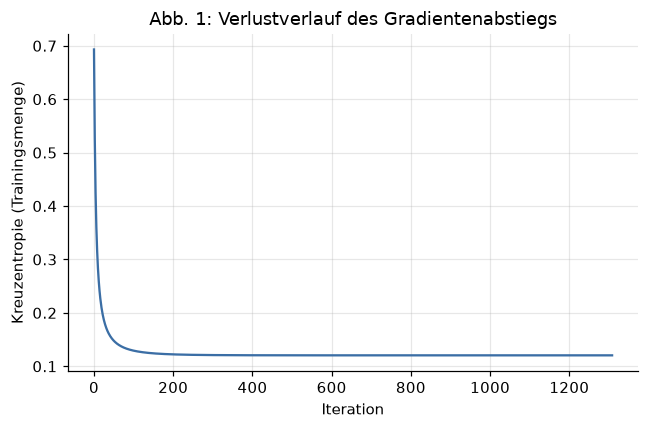

In [5]:
model = LogisticRegressionScratch(learning_rate=0.5, n_iter=3000).fit(X_train, y_train)

print(f"Konvergiert nach {model.n_iter_} Iterationen")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Koeffizienten: {model.coef_}")

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(model.loss_history_, color="#3b6ea5")
ax.set_xlabel("Iteration")
ax.set_ylabel("Kreuzentropie (Trainingsmenge)")
ax.set_title("Abb. 1: Verlustverlauf des Gradientenabstiegs")
plt.tight_layout()
plt.show()

### 6.2 Entscheidungsgrenzen: linear trennbar vs. Halbmonde

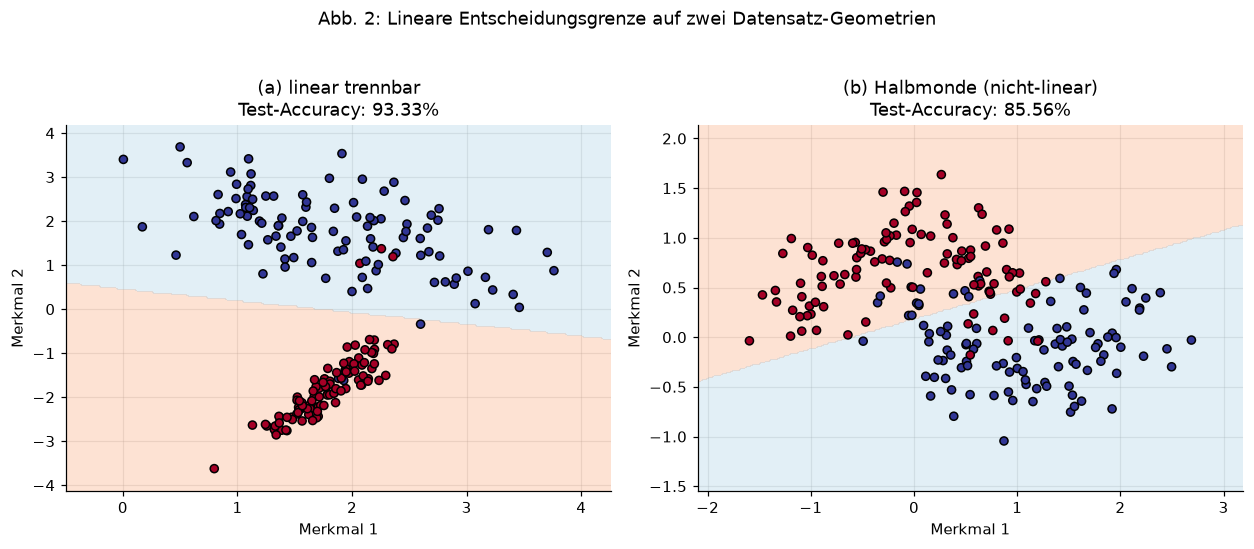

In [6]:
def plot_decision_boundary(model, X, y, title, ax, predict_fn=None):
    """Zeichnet die Entscheidungsgrenze eines binaeren Klassifikators.

    Parameters
    ----------
    model : Objekt mit .predict(X) oder ueber predict_fn ansprechbar
    X, y : Trainings- bzw. Anzeigedaten (n, 2) und (n,)
    title : Plot-Titel
    ax : Matplotlib-Achse
    predict_fn : callable, optional
        Falls gesetzt, wird predict_fn(model, X) statt model.predict(X) verwendet.
    """
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = predict_fn(model, grid) if predict_fn else model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="RdYlBu", s=28)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")
    ax.set_title(title)


model_moons = LogisticRegressionScratch(learning_rate=0.5, n_iter=3000).fit(Xm_train, ym_train)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
acc_lin = classification_metrics(y_test, model.predict(X_test))["accuracy"]
acc_moons = classification_metrics(ym_test, model_moons.predict(Xm_test))["accuracy"]
plot_decision_boundary(model, X_train, y_train,
                        f"(a) linear trennbar\nTest-Accuracy: {acc_lin:.2%}", axes[0])
plot_decision_boundary(model_moons, Xm_train, ym_train,
                        f"(b) Halbmonde (nicht-linear)\nTest-Accuracy: {acc_moons:.2%}", axes[1])
fig.suptitle("Abb. 2: Lineare Entscheidungsgrenze auf zwei Datensatz-Geometrien", y=1.03)
plt.tight_layout()
plt.show()

**Interpretation.** Auf dem linear trennbaren Datensatz erreicht das Modell hohe
Testgenauigkeit mit einer nahezu optimal platzierten Trenngerade. Auf den Halbmonden
ist die Klasseneinteilung durch keine Gerade korrekt reproduzierbar — die
Entscheidungsgrenze schneidet zwangsläufig durch beide Halbmonde. Dies ist keine Frage
der Optimierung (der Gradientenabstieg konvergiert in beiden Fällen), sondern eine
strukturelle Grenze des **linearen** Modells (Abschnitt 2.4). Abhilfe schaffen
Merkmalstransformationen (z.\,B. polynomiale Merkmale), Kernel-Methoden oder
nicht-lineare Modelle wie der Entscheidungsbaum (Notebook 04) oder das neuronale Netz
(Notebook 08).

### 6.3 Klassifikationsgüte und ROC-Analyse

Konfusionsmatrix (Testmenge, linear trennbar):


,vorhergesagt 0,vorhergesagt 1
tatsächlich 0,43,2
tatsächlich 1,4,41



Accuracy:  0.9333
Precision: 0.9535
Recall:    0.9111
F1-Score:  0.9318


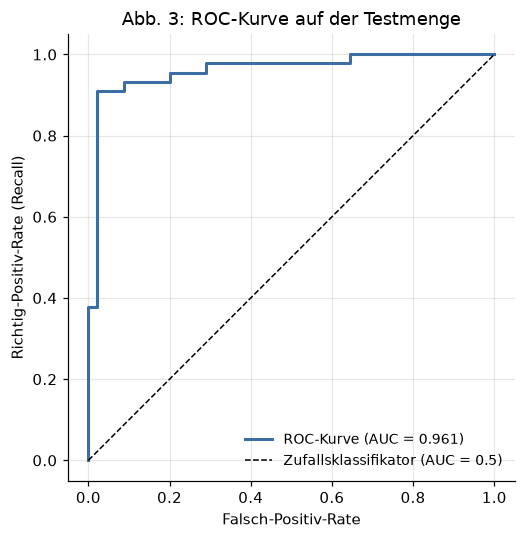

In [7]:
y_pred_test = model.predict(X_test)
y_scores_test = model.predict_proba(X_test)

metrics_result = classification_metrics(y_test, y_pred_test)
print("Konfusionsmatrix (Testmenge, linear trennbar):")
cm = pd.DataFrame(
    [[metrics_result["TN"], metrics_result["FP"]], [metrics_result["FN"], metrics_result["TP"]]],
    index=["tatsächlich 0", "tatsächlich 1"], columns=["vorhergesagt 0", "vorhergesagt 1"],
)
display(cm)
print(f"\nAccuracy:  {metrics_result['accuracy']:.4f}")
print(f"Precision: {metrics_result['precision']:.4f}")
print(f"Recall:    {metrics_result['recall']:.4f}")
print(f"F1-Score:  {metrics_result['f1']:.4f}")

fpr, tpr, auc = roc_curve_scratch(y_test, y_scores_test)

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.plot(fpr, tpr, color="#3b6ea5", lw=2, label=f"ROC-Kurve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Zufallsklassifikator (AUC = 0.5)")
ax.set_xlabel("Falsch-Positiv-Rate")
ax.set_ylabel("Richtig-Positiv-Rate (Recall)")
ax.set_title("Abb. 3: ROC-Kurve auf der Testmenge")
ax.legend(fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### 6.4 Kalibrierung

Ein Modell ist **kalibriert**, wenn unter allen Vorhersagen mit
$\hat p(\mathbf{x})\approx q$ auch tatsächlich ein Anteil $q$ zur Klasse 1 gehört.
Kalibrierung ist von der Diskriminierungsfähigkeit (AUC) begrifflich zu trennen: Ein
Modell kann Klassen gut trennen, ohne dass seine Wahrscheinlichkeiten kalibriert sind.

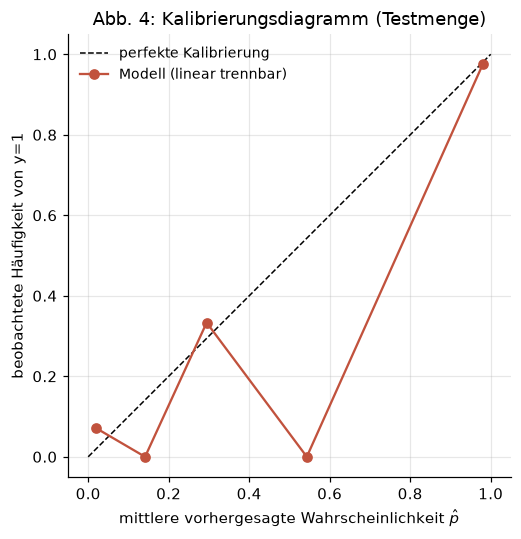

In [8]:
n_bins = 8
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_idx = np.clip(np.digitize(y_scores_test, bin_edges) - 1, 0, n_bins - 1)

observed_freq, mean_pred = [], []
for b in range(n_bins):
    mask = bin_idx == b
    if mask.sum() > 0:
        observed_freq.append(y_test[mask].mean())
        mean_pred.append(y_scores_test[mask].mean())

fig, ax = plt.subplots(figsize=(5.0, 5.0))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfekte Kalibrierung")
ax.plot(mean_pred, observed_freq, "o-", color="#c1523d", label="Modell (linear trennbar)")
ax.set_xlabel(r"mittlere vorhergesagte Wahrscheinlichkeit $\hat p$")
ax.set_ylabel("beobachtete Häufigkeit von y=1")
ax.set_title("Abb. 4: Kalibrierungsdiagramm (Testmenge)")
ax.legend(fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Interpretation.** Liegen die Punkte nahe der Diagonalen, entsprechen die vom Modell
ausgegebenen Wahrscheinlichkeiten in etwa den beobachteten Häufigkeiten — die
logistische Regression ist durch ihre Herleitung aus der Bernoulli-Likelihood
(Abschnitt 2.2) tendenziell gut kalibriert, sofern das lineare Logit-Modell korrekt
spezifiziert ist. Modelle wie unregulierte tiefe Entscheidungsbäume erreichen oft hohe
AUC bei gleichzeitig schlechter Kalibrierung (systematisch zu extreme
Wahrscheinlichkeiten).

### 6.5 Validierung gegen `scikit-learn`

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
)

reference = LogisticRegression(penalty=None, max_iter=5000).fit(X_train, y_train)
y_pred_ref = reference.predict(X_test)
y_scores_ref = reference.predict_proba(X_test)[:, 1]

validation = pd.DataFrame(
    {
        "Eigenimplementierung": [
            model.intercept_, *model.coef_,
            metrics_result["accuracy"], metrics_result["precision"],
            metrics_result["recall"], metrics_result["f1"], auc,
        ],
        "scikit-learn": [
            reference.intercept_[0], *reference.coef_[0],
            accuracy_score(y_test, y_pred_ref), precision_score(y_test, y_pred_ref),
            recall_score(y_test, y_pred_ref), f1_score(y_test, y_pred_ref),
            roc_auc_score(y_test, y_scores_ref),
        ],
    },
    index=["intercept", "coef_1", "coef_2", "accuracy", "precision", "recall", "f1", "AUC"],
)
validation["absolute Differenz"] = (
    validation["Eigenimplementierung"] - validation["scikit-learn"]
).abs()
display(validation)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Eigenimplementierung,scikit-learn,absolute Differenz
intercept,-1.1033,-1.1029,3.7060e-04
coef_1,0.6447,0.6449,1.8146e-04
coef_2,2.4127,2.4132,5.2819e-04
accuracy,0.9333,0.9333,0.0000e+00
precision,0.9535,0.9535,0.0000e+00
recall,0.9111,0.9111,0.0000e+00
f1,0.9318,0.9318,1.1102e-16
AUC,0.9610,0.9610,1.1102e-16


**Interpretation.** Die Koeffizienten stimmen bis auf geringe numerische Abweichungen
überein; verbleibende Differenzen resultieren aus dem unterschiedlichen
Optimierungsverfahren (Gradientenabstieg auf standardisierten Merkmalen vs. LBFGS von
`scikit-learn`) und der endlichen Anzahl an Iterationen, nicht aus einem
unterschiedlichen statistischen Modell. Die abgeleiteten Klassifikationsgütemaße
stimmen praktisch exakt überein, da sie ausschließlich von den (nahezu identischen)
Vorhersagen abhängen.

<a id="7"></a>
## 7 Diskussion und Grenzen

**Ergebnis.** Die Eigenimplementierung reproduziert `scikit-learn` und liefert auf dem
linear trennbaren Datensatz hohe Testgenauigkeit sowie eine plausible Kalibrierung.
Auf dem Halbmond-Datensatz zeigt sich die strukturelle Grenze linearer
Entscheidungsgrenzen deutlich.

**Methodische Einschränkungen.**

1. *Keine Regularisierung.* Bei perfekter linearer Trennbarkeit divergieren die
   Koeffizienten der unregulierten MLE-Lösung gegen Unendlich (die Sigmoid-Funktion
   nähert sich beliebig genau einer Stufenfunktion an). `scikit-learn` regularisiert
   standardmäßig ($\ell_2$); die Eigenimplementierung hier bewusst nicht, um die reine
   MLE-Herleitung zu zeigen.
2. *Unbalancierte Klassen.* Bei stark unbalancierten Zielgrößen ist Accuracy
   irreführend; Precision, Recall und die ROC-AUC sind dann informativer, im
   Extremfall auch die Precision-Recall-Kurve.
3. *Lineares Logit.* Nicht-lineare Zusammenhänge im Logit erfordern
   Merkmalstransformationen oder ein anderes Modell (Notebooks 04, 08).
4. *Ein einzelner Split.* Wie in Notebook 01 unterliegen die Testkennzahlen der
   Stichprobenvarianz eines einzelnen Splits.

**Anschluss.** Notebook 03 verlässt das parametrische, lineare Modell zugunsten eines
nicht-parametrischen, lokal adaptiven Klassifikators (k-Nearest Neighbors).

<a id="8"></a>
## 8 Übungsaufgaben

1. **Divergenz bei perfekter Trennbarkeit.** Erzeugen Sie einen perfekt linear
   trennbaren Datensatz (`class_sep` stark erhöhen, `flip_y=0`). Beobachten Sie die
   Koeffizientennorm $\lVert\hat{\boldsymbol\beta}\rVert$ über die Iterationen.
2. **Polynomiale Merkmale.** Erweitern Sie die Halbmond-Daten um $x_1^2, x_2^2, x_1 x_2$
   und passen Sie die logistische Regression erneut an. Vergleichen Sie die
   Entscheidungsgrenze mit Abb. 2(b).
3. **Unbalancierte Klassen.** Erzeugen Sie einen Datensatz mit 95:5-Klassenverteilung
   (Parameter `weights` in `make_classification`). Vergleichen Sie Accuracy und
   F1-Score eines Klassifikators, der stets die Mehrheitsklasse vorhersagt, mit dem
   trainierten Modell.
4. **Schwellenwert-Wahl.** Bestimmen Sie den Schwellenwert $\tau\neq 0.5$, der den
   F1-Score auf der Testmenge maximiert, und vergleichen Sie die resultierende
   Konfusionsmatrix mit der bei $\tau=0.5$.
5. **Regularisierung.** Ergänzen Sie den Gradienten um einen $\ell_2$-Strafterm
   $\lambda\boldsymbol\beta$ (ohne den Achsenabschnitt) und untersuchen Sie den Effekt
   auf die Koeffizientennorm bei perfekter Trennbarkeit (siehe Aufgabe 1).

<a id="9"></a>
## 9 Literatur

* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical
  Learning* (2. Aufl.). Springer. Kap. 4.
* James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to
  Statistical Learning* (2. Aufl.). Springer. Kap. 4.
* Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*,
  27(8), 861–874.
* Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with
  supervised learning. *ICML 2005*.